In [31]:
import pandas as pd

# wczytuje dane
df = pd.read_csv('train.csv')

# sprawdzam kolumny
print("Dane wczytane pomyślnie!")
df.head()

Dane wczytane pomyślnie!


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [32]:
from sklearn.preprocessing import LabelEncoder

# wybieram cechy: rok budowy (YearBuilt), jakość (OverallQual), metraż (GrLivArea), liczbę pokoi (TotRmsAbvGrd), dzielnicę (Neighborhood), kuchnię (KitchenQual), garaż (GarageCars), piwnicę (TotalBsmtSF), działkę (LotArea), łazienki (FullBath), elewację (ExterQual) oraz cenę (SalePrice)
selected_columns = [
    'YearBuilt', 'OverallQual', 'GrLivArea', 'TotRmsAbvGrd', 
    'Neighborhood', 'KitchenQual', 'GarageCars', 'TotalBsmtSF', 
    'LotArea', 'FullBath', 'ExterQual', 'SalePrice'
]

# kopia danych
data = df[selected_columns].copy()

# kodowanie słów na liczby dotyczy Neighborhood, KitchenQual oraz ExterQual
le = LabelEncoder()

data['Neighborhood'] = le.fit_transform(data['Neighborhood'])
data['KitchenQual'] = le.fit_transform(data['KitchenQual'].fillna('TA'))
data['ExterQual'] = le.fit_transform(data['ExterQual'].fillna('TA'))

# oczyszczenie danych, bo nieruchomość może być bez garażu lub piwnicy lub łazienki
data['TotalBsmtSF'] = data['TotalBsmtSF'].fillna(0)
data['GarageCars'] = data['GarageCars'].fillna(0)
data['FullBath'] = data['FullBath'].fillna(0)
data['LotArea'] = data['LotArea'].fillna(data['LotArea'].median())

# Sprawdzam, czy nie występuje "brak danych"
print("Brakujące wartości:")
print(data.isnull().sum())

# Statystyki
data.describe()

Brakujące wartości:
YearBuilt       0
OverallQual     0
GrLivArea       0
TotRmsAbvGrd    0
Neighborhood    0
KitchenQual     0
GarageCars      0
TotalBsmtSF     0
LotArea         0
FullBath        0
ExterQual       0
SalePrice       0
dtype: int64


,YearBuilt,OverallQual,GrLivArea,TotRmsAbvGrd,Neighborhood,KitchenQual,GarageCars,TotalBsmtSF,LotArea,FullBath,ExterQual,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,1971.267808,6.099315,1515.463699,6.517808,12.251370,2.339726,1.767123,1057.429452,10516.828082,1.565068,2.539726,180921.195890
std,30.202904,1.382997,525.480383,1.625393,6.013735,0.830161,0.747315,438.705324,9981.264932,0.550916,0.693995,79442.502883
min,1872.000000,1.000000,334.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1300.000000,0.000000,0.000000,34900.000000
25%,1954.000000,5.000000,1129.500000,5.000000,7.000000,2.000000,1.000000,795.750000,7553.500000,1.000000,2.000000,129975.000000
50%,1973.000000,6.000000,1464.000000,6.000000,12.000000,3.000000,2.000000,991.500000,9478.500000,2.000000,3.000000,163000.000000
75%,2000.000000,7.000000,1776.750000,7.000000,17.000000,3.000000,2.000000,1298.250000,11601.500000,2.000000,3.000000,214000.000000
max,2010.000000,10.000000,5642.000000,14.000000,24.000000,3.000000,4.000000,6110.000000,215245.000000,3.000000,3.000000,755000.000000


In [33]:
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Wybieram zestaw cech "data" przygotowany wcześniej
X = data.drop('SalePrice', axis=1) 

# 2. skala logarytmiczna dla ceny wykres (y)
y = np.log1p(data['SalePrice'])

# 3. Podział na dane treningowe i testowe w stosunku 4:1 i seed 43
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

print(f"Liczba domów do nauki: {len(X_train)}")
print(f"Liczba domów do testu: {len(X_test)}")
print("---")
print("Status: Cena (y) została zlogarytmowana. Model będzie teraz szukał zależności nieliniowych.")

Liczba domów do nauki: 1168
Liczba domów do testu: 292
---
Status: Cena (y) została zlogarytmowana. Model będzie teraz szukał zależności nieliniowych.


In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Tworzenie modelu zmiennej
model_lin_v2 = LinearRegression()

# 2. Trenowanie na zlogarytmowanych danych (y_train to teraz logarytmy)
model_lin_v2.fit(X_train, y_train)

# 3. Predykcja wyniku
y_pred_log = model_lin_v2.predict(X_test)

# odwrócenie logarytmu, czyli powrót do danych w kwotach
y_pred_usd = np.expm1(y_pred_log)
y_test_usd = np.expm1(y_test)

# 4. Obliczenie błędu MAE (Mean Absolute Error) – Średni Błąd Bezwzględny i RMSE (Root Mean Squared Error) – Pierwiastek Błędu Średniokwadratowego
mae = mean_absolute_error(y_test_usd, y_pred_usd)
rmse = np.sqrt(mean_squared_error(y_test_usd, y_pred_usd))

print(f"REGRESJA LINIOWA - Błąd MAE: ${mae:,.2f}")
print(f"REGRESJA LINIOWA - Błąd RMSE: ${rmse:,.2f}")

REGRESJA LINIOWA - Błąd MAE: $21,816.47
REGRESJA LINIOWA - Błąd RMSE: $49,002.44


In [35]:
from sklearn.ensemble import RandomForestRegressor

# 1. Ze względu że uzyskałem błąd na poziomie 22 tys usd tworzę las analityków aby sprawdzić czy uda zejść się poniżej 20 tys USD (500 analityków, niech się wykażą)
model_rf_final = RandomForestRegressor(n_estimators=500, random_state=43)

# 2. Trening na danych (X_train i zlogarytmowane y_train)
model_rf_final.fit(X_train, y_train)

# 3. Predykcja
y_pred_log_rf = model_rf_final.predict(X_test)

# 4. Odwracam logarytm aby wrócić do kwot w dolarach
y_pred_usd_rf = np.expm1(y_pred_log_rf)
y_test_usd = np.expm1(y_test)

# 5. Obliczenie błędu końcowego MAE (Mean Absolute Error) – Średni Błąd Bezwzględny i RMSE (Root Mean Squared Error) – Pierwiastek Błędu Średniokwadratowego
mae_rf = mean_absolute_error(y_test_usd, y_pred_usd_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_usd, y_pred_usd_rf))

print(f"LAS LOSOWY - Błąd MAE: ${mae_rf:,.2f}")
print(f"LAS LOSOWY - Błąd RMSE: ${rmse_rf:,.2f}")

LAS LOSOWY - Błąd MAE: $21,048.58
LAS LOSOWY - Błąd RMSE: $38,390.78


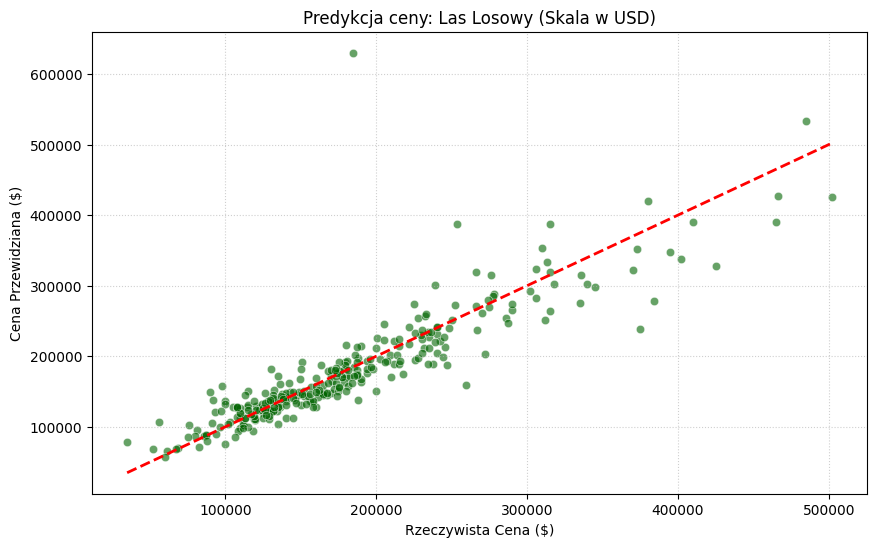

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 6))

# Odwrócenie logarytmu do kwot w usd
y_test_usd = np.expm1(y_test)
y_pred_usd = np.expm1(y_pred_log_rf)

# Rysuje kropki (test.csv vs predykcja w dolarach)
sns.scatterplot(x=y_test_usd, y=y_pred_usd, alpha=0.6, color='darkgreen')

# Rysuje czerwoną linię idealnej predykcji
plt.plot([y_test_usd.min(), y_test_usd.max()], [y_test_usd.min(), y_test_usd.max()], '--r', lw=2)

# Formatowanie osi na czytelne kwoty
plt.xlabel('Rzeczywista Cena ($)')
plt.ylabel('Cena Przewidziana ($)')
plt.title('Predykcja ceny: Las Losowy (Skala w USD)')

# Dodanie siatki dla lepszego odczytu
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

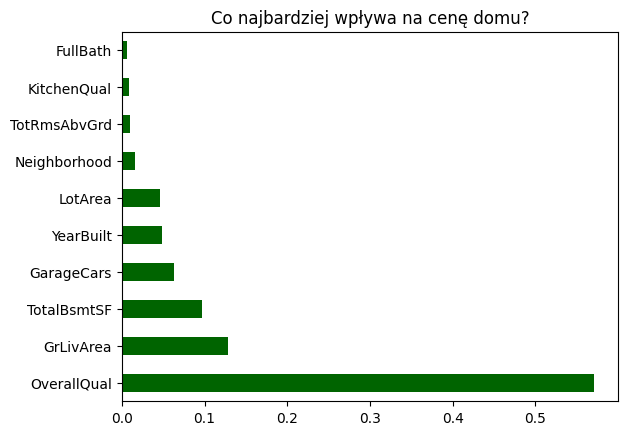

In [37]:
# Sprawdzenie, co miało największy wpływ na cenę
import pandas as pd

importances = pd.Series(model_rf_final.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='darkgreen')
plt.title('Co najbardziej wpływa na cenę domu?')
plt.show()